In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (
    Xception, VGG16, VGG19, ResNet50, ResNet50V2, ResNet101, ResNet101V2,
    ResNet152, ResNet152V2, MobileNet
)
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50


# 1. Load CIFAR-10 dataset


In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import (
    Xception, VGG16, VGG19, ResNet50, ResNet50V2, ResNet101, ResNet101V2,
    ResNet152, ResNet152V2, MobileNet
)

(_, _), (x_test, y_test) = cifar10.load_data()
img = tf.image.resize(x_test[0:1], (224, 224)) / 255.0
models = [
    Xception(weights='imagenet', include_top=False),
    VGG16(weights='imagenet', include_top=False),
    VGG19(weights='imagenet', include_top=False),
    ResNet50(weights='imagenet', include_top=False),
    ResNet50V2(weights='imagenet', include_top=False),
    ResNet101(weights='imagenet', include_top=False),
    ResNet101V2(weights='imagenet', include_top=False),
    ResNet152(weights='imagenet', include_top=False),
    ResNet152V2(weights='imagenet', include_top=False),
    MobileNet(weights='imagenet', include_top=False),
]

# Extract and visualize feature maps
for model in models:
    model_name = model.name
    print(f"\nModel: {model_name}")
    feature_maps = model.predict(img)
    print(f"Feature map shape: {feature_maps.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/tmp/ipython-input-3861605430.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  MobileNet(weights='imagenet', include_top=False),


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model: xception
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Feature map shape: (1, 7, 7, 2048)

Model: vgg16
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Feature map shape: (1, 7, 7, 512)

Model: vgg19
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 972ms/step
Feature map shape: (1, 7, 7, 512)

Model: resnet50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Feature map shape: (1, 7, 7, 2048)

Model: resnet50v2


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Feature map shape: (1, 7, 7, 2048)

Model: resnet101


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Feature map shape: (1, 7, 7, 2048)

Model: resnet101v2
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Feature map shape: (1, 7, 7, 2048)

Model: resnet152
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Feature map shape: (1, 7, 7, 2048)

Model: resnet152v2
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Feature map shape: (1, 7, 7, 2048)

Model: mobilenet_1.00_224
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Feature map shape: (1, 7, 7, 1024)



# 2. Load 10 pretrained CNN models


In [4]:

models_dict = {
    "Xception": Xception(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "VGG16": VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "VGG19": VGG19(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet50": ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet50V2": ResNet50V2(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet101": ResNet101(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet101V2": ResNet101V2(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet152": ResNet152(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet152V2": ResNet152V2(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "MobileNet": MobileNet(weights="imagenet", include_top=False, input_shape=(224,224,3)),
}

# 3. Analyze activation functions

In [5]:

activation_summary = {}

for name, model in models_dict.items():
    activations = set()
    for layer in model.layers:
        if hasattr(layer, 'activation'):
            act = layer.activation.__name__
            activations.add(act)
    activation_summary[name] = list(activations)

# Print summary
print("\n=== Activation Functions Summary ===")
for name, acts in activation_summary.items():
    print(f"{name}: {acts}")


=== Activation Functions Summary ===
Xception: ['linear', 'relu']
VGG16: ['relu']
VGG19: ['relu']
ResNet50: ['linear', 'relu']
ResNet50V2: ['linear', 'relu']
ResNet101: ['linear', 'relu']
ResNet101V2: ['linear', 'relu']
ResNet152: ['linear', 'relu']
ResNet152V2: ['linear', 'relu']
MobileNet: ['linear']


# 4. Kernel type categorization

# 5. Visualize feature maps for one CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


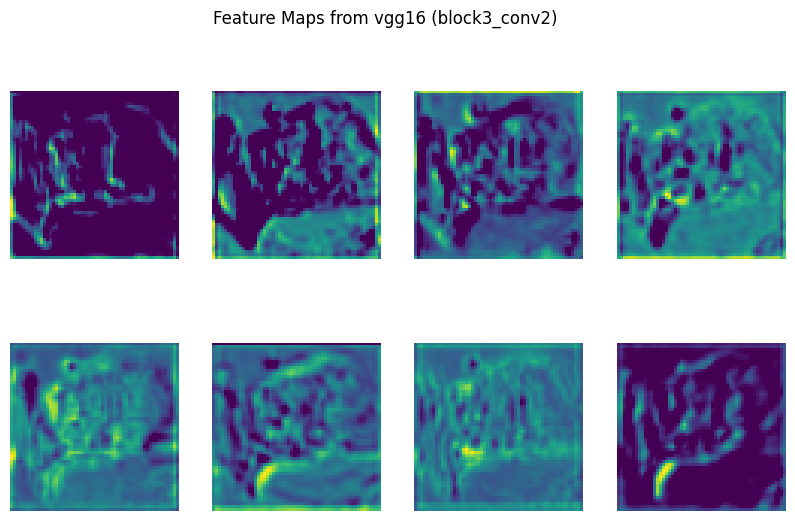

In [6]:
# Load CIFAR-10 test data
(_, _), (x_test, y_test) = cifar10.load_data()
sample_img = tf.image.resize(x_test[0:1], (224, 224)) / 255.0  # shape (1, 224, 224, 3)
chosen_model = VGG16(weights='imagenet', include_top=False)
layer_names = [layer.name for layer in chosen_model.layers if 'conv' in layer.name]
intermediate_layer_model = tf.keras.Model(
    inputs=chosen_model.input,
    outputs=[chosen_model.get_layer(layer_names[5]).output]
)

feature_maps = intermediate_layer_model.predict(sample_img)

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f"Feature Maps from {chosen_model.name} ({layer_names[5]})")
plt.show()
